In [1]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
# Lista para alocar os dados da contagem de partículas
particulas = []

# Função para contar a quantidade de partículas em cada linha TRIG
def contar_particulas(evento):
    contagem = {}
    for linha in evento:
        partes = linha.split()
        if partes[0].startswith("TRIG"):
            contagem[partes[0]] = len(partes) - 1  
    return contagem

# Função para processar o arquivo e contar as partículas em cada evento
def contar_particulas_em_eventos(nome_arquivo):
    with open(nome_arquivo, 'r') as arquivo:
        linhas = arquivo.readlines()
    
    eventos = []
    evento_atual = []
    
    for linha in linhas:
        if linha.startswith("EVTE"):
            eventos.append(evento_atual)
            evento_atual = []
        evento_atual.append(linha)
    
    # Contagem da quantidade de partículas em cada linha TRIG em cada evento
    for i, evento in enumerate(eventos):
        contagem = contar_particulas(evento)
        #print(f"Evento {i + 1}:")
        for linha_trig, quantidade in contagem.items():
            #print(f"{linha_trig}: {quantidade} partículas")
            particulas.append(contagem)

if __name__ == "__main__":
    arquivo = "TESTE5"  
    contar_particulas_em_eventos(arquivo)


In [3]:
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5

trig1 = []
trig2 = []
trig3 = []

type(particulas[20])

dict

In [4]:
trigs = []
for i in particulas:
    trigs_aux = list(i.values())
    trigs.append(trigs_aux)

In [5]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig1.append(sublista[0])

In [6]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig2.append(sublista[1])

In [7]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig3.append(sublista[2])

In [8]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [9]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/65).alias('rho1'),
        (pl.col('trig2')/65).alias('rho2'),
        (pl.col('trig3')/65).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (df['r_b']-r1).alias('r1_b'),
        (df['r_b']-r2).alias('r2_b'),
        (df['r_b']-r3).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
13.490196,-11.269499,0.29,0.21,0.14,40.259104,0.004462,0.003231,0.002154,-305.740896,-488.622735,-488.622735


[0.004461538461538462, 0.003230769230769231, 0.0021538461538461538] [-305.74089580292656, -488.622735158373, -488.622735158373]


Text(0, 0.5, '$\\rho$')

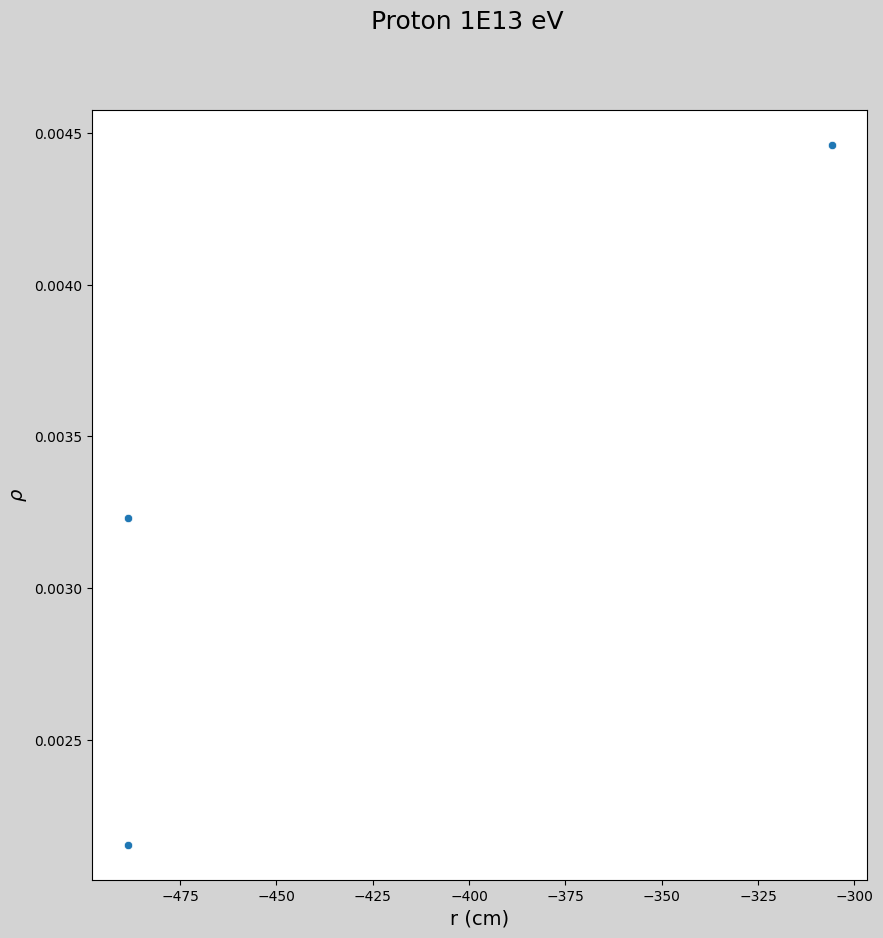

In [11]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)

fig, ax = plt.subplots(1, 1, figsize = (10, 10), facecolor = 'lightgray')
fig.suptitle('Proton 1E13 eV', size = 18)
sns.scatterplot(x = r_b, y = rho, ax = ax)

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho$', size = 14)
